In [115]:
from keras import datasets
from keras import layers
from keras import models
from keras import utils
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

%matplotlib inline

In [120]:
def show_img(image,label):
  
    im_shape = image.shape

    f, ax = plt.subplots(1,1,figsize=(11,11)) 
    ax.set_xticks(range(im_shape[0]))
    ax.set_yticks(range(im_shape[1]))

    ax.imshow(image,cmap='gray')

    for i in range(im_shape[0]):
        for j in range(im_shape[1]):
            ax.text(i,j,s=str(round(image[j,i],3)),c='w',ha='center',size='x-small')

    ax.set_title(f'LABEL : {label}')

In [121]:
def show_process(n,autoencoder,encoder,x,y):
    
    n = 8

    f, ax = plt.subplots(3,n,figsize=(25,8))

    idxs_sample        = np.random.choice(range(x.shape[0]),n)
    original_imgs      = x[idxs_sample]
    original_labels    = y[idxs_sample]
    encoded_imgs       = encoder.predict(original_imgs).reshape(n,2,16)
    reconstructed_imgs = autoencoder.predict(original_imgs).reshape(n,28,28)


    for i in range(3):
        for j in range(n):
            if i == 0:
                ## plotando as originais
                ax[i,j].imshow(original_imgs[j].reshape(28,28),cmap='gray')
                ax[i,j].set_title(original_labels[j])
                ax[i,j].axis('off')

            elif i == 1:
                ## plotando os vetores latentes
                ax[i,j].imshow(encoded_imgs[j].reshape(2,16),cmap='gray')
                ax[i,j].axis('off')

            else:
                ## plotando os vetores latentes
                ax[i,j].imshow(reconstructed_imgs[j].reshape(28,28),cmap='gray')
                ax[i,j].axis('off')

In [122]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = x_train / 255
x_test = x_test / 255

x_train.shape,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [123]:
## reshaping

x_train,x_test = x_train.reshape(x_train.shape[0],np.prod(x_train.shape[1:])),x_test.reshape(x_test.shape[0],np.prod(x_test.shape[1:]))
x_train.shape,x_test.shape

((60000, 784), (10000, 784))

## Autoencoder

In [129]:
input_img = layers.Input(shape=(784,))

## encoder
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

## decoder
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

## modelo
autoencoder = models.Model(input_img,decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

## encoder
encoder = models.Model(input_img,encoded)

In [130]:
history = autoencoder.fit(x_train, x_train,
                epochs=200,
                batch_size=256,
                validation_data=(x_test, x_test),
                verbose=0)

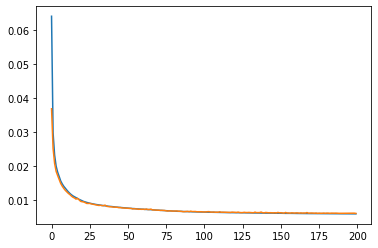

In [136]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [111]:
x_train_new = encoder.predict(x_train)
x_test_new = encoder.predict(x_test)

rf = RandomForestClassifier(n_estimators = 300,n_jobs=-1,min_samples_leaf=100,max_features=32,random_state=42)
rf.fit(x_train_new,y_train)

RandomForestClassifier(max_features=32, min_samples_leaf=100, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [112]:
pred_new = rf.predict(x_test_new)

In [113]:
print(classification_report(y_test,pred_new))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       980
           1       0.93      0.95      0.94      1135
           2       0.77      0.79      0.78      1032
           3       0.73      0.80      0.76      1010
           4       0.79      0.83      0.81       982
           5       0.76      0.74      0.75       892
           6       0.84      0.88      0.86       958
           7       0.88      0.78      0.83      1028
           8       0.75      0.69      0.72       974
           9       0.80      0.79      0.80      1009

    accuracy                           0.82     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.82      0.82     10000



# Modelo

In [13]:
input_img = layers.Input(shape=(784,))

## encoder
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

## decoder
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

## modelo
autoencoder = models.Model(input_img,decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

## encoder
encoder = models.Model(input_img,encoded)

In [14]:
autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256,
                validation_data=(x_test, x_test),
                verbose=1)

Epoch 1/100
235/235 [==============================] - 1s 3ms/step - loss: 0.2330 - val_loss: 0.1622
Epoch 2/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1447 - val_loss: 0.1292
Epoch 3/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1254 - val_loss: 0.1192
Epoch 4/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1175 - val_loss: 0.1134
Epoch 5/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1126 - val_loss: 0.1094
Epoch 6/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1087 - val_loss: 0.1061
Epoch 7/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1060 - val_loss: 0.1040
Epoch 8/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1041 - val_loss: 0.1023
Epoch 9/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1025 - val_loss: 0.1005
Epoch 10/100
235/235 [==============================] - 1s 3ms/step - loss: 0.1007 - val_lo

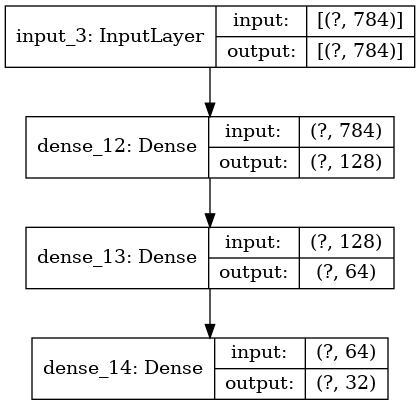

In [87]:
utils.plot_model(encoder,show_shapes=True)

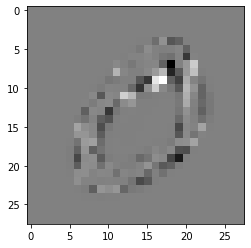

In [81]:
plt.imshow((x_train[1] - autoencoder.predict(x_train[1].reshape(1,784,))).reshape(28,28),cmap='gray')

In [84]:
autoencoder.predict(x_train[1].reshape(1,784,)).max()

0.99607855

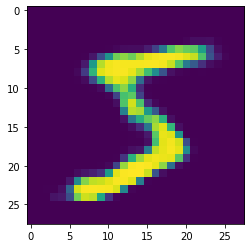

In [ ]:
plt.imshow(preds[0])


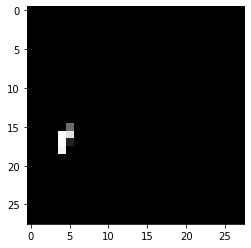

In [ ]:
plt.imshow(encoded[0].reshape(28,28))

In [ ]:
autoencoder.predict(x_train[1].reshape(1,784)).reshape(28,28)

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000

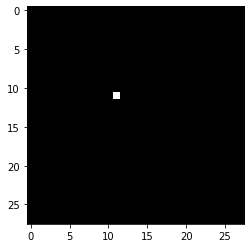

In [ ]:
plt.imshow(autoencoder.predict(x_train[1].reshape(1,784)).reshape(28,28))